In [1]:
"..."

'...'

In [2]:
import torch
from torch.nn import functional as F
from spehere_encoder_cifra_10 import Model_Wrapper, CIFAR10AutoencoderDataset
from torch.utils.data import Dataset, DataLoader
from matplotlib import pyplot as plt


In [3]:
# Setup model and config
# batch_size = 32
# img_size = 32
# patch_size = 16
# in_channels = 3
# hidden_dim = 512
# latent_channels = 256
# num_classes = 1000
# num_heads = 8
# depth = 8

batch_size = 64
img_size = 32
patch_size = 2
in_channels = 3
hidden_dim = 384
latent_channels = 8
num_classes = 10
num_heads = 6
depth = 12


dataset = CIFAR10AutoencoderDataset(train=False)
data_loader = DataLoader(dataset, batch_size=64)

model = Model_Wrapper(
    img_size=img_size, 
    patch_size=patch_size, 
    in_channels=in_channels, 
    hidden_dim=hidden_dim, 
    latent_channels=latent_channels,
    num_classes=num_classes,
    num_heads=num_heads,
    depth=depth,
)

/home/daniel/home/sph_encoder/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
checkpoint = torch.load("/home/daniel/home/sph_encoder/runs8/cifar10_test/interrupted_latest.pt")

In [5]:
# checkpoint['model_state']
model.load_state_dict(checkpoint['model_state'])

<All keys matched successfully>

In [52]:
data_loader_iter = iter(data_loader)
inputs, labels = next(data_loader_iter)
model.eval()
with torch.no_grad():
    samples = model(inputs, labels)

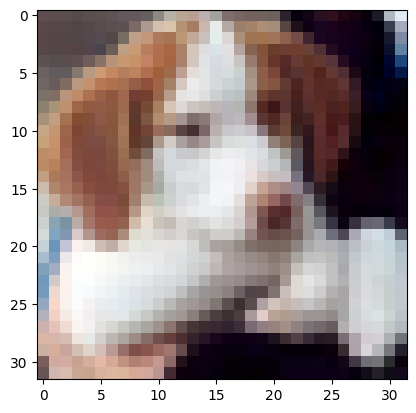

In [8]:
plt.imshow(((inputs[16]  + 1) / 2).permute(1, 2, 0).numpy())

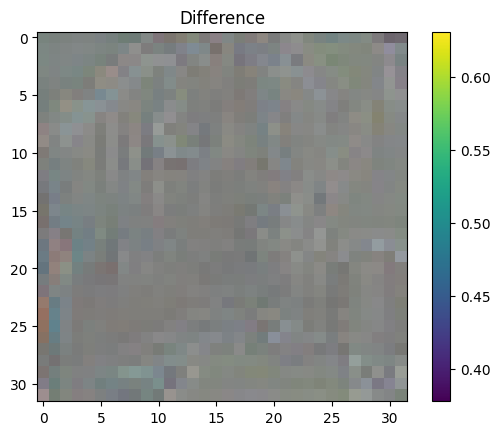

In [24]:
plt.imshow(((samples['x_noisy'] - samples['x'])[16].permute(1, 2, 0) + 1) / 2)
plt.title("Difference")
plt.colorbar()
plt.show()

In [35]:
nnoisy.shape

torch.Size([64, 256, 8])

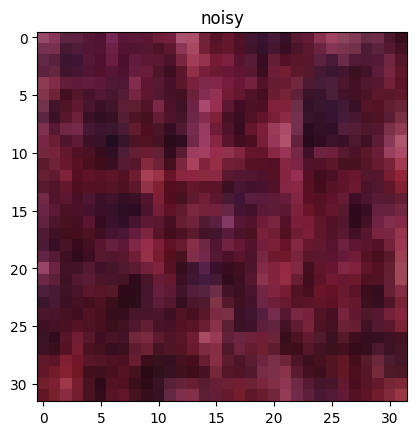

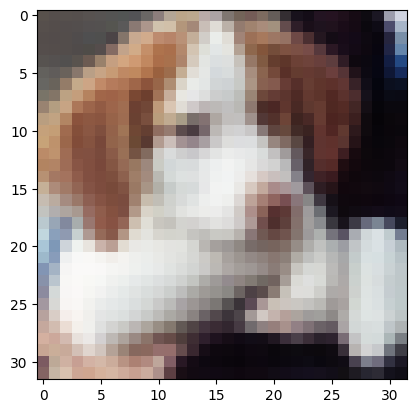

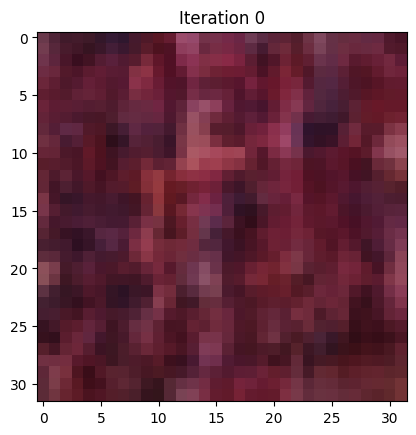

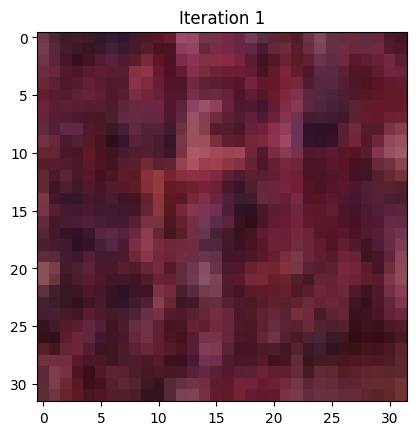

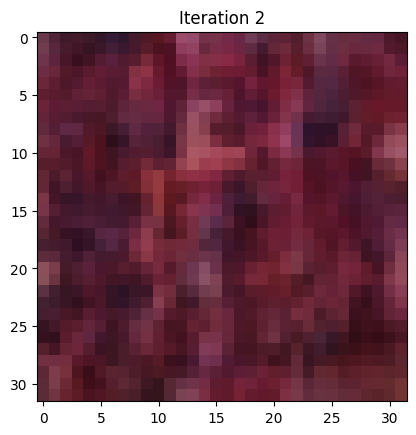

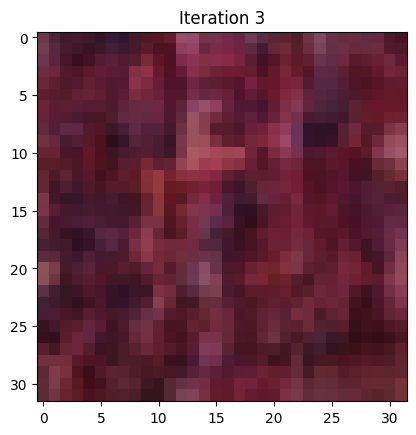

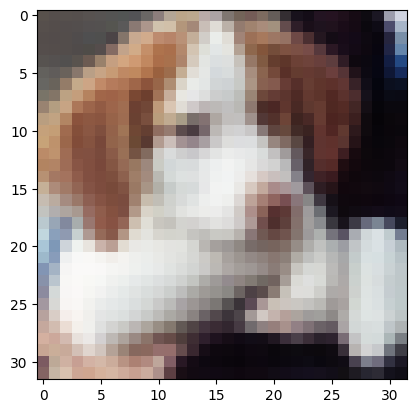

In [37]:
index = 16
noisy = samples['x_noisy']

# cached_noise = torch.randn(torch.Size([64, 256, 8]), device="cpu")

latents_shape = samples["v_one_step"].shape
# view_shape = (latents_shape[0],) + (1,) * (len(latents_shape) - 1)
# sigma_max = torch.tan(torch.deg2rad(torch.tensor([85], device="cpu", dtype=torch.float32))).item()
# sigma = sigma_max * torch.rand(latents_shape, device="cpu").view(view_shape)
vnnoisy = F.rms_norm((torch.rand_like(samples["v_one_step"])), samples["v_one_step"].shape[1:], eps=1e-6)
with torch.inference_mode():
    nnoisy = model.model.decoder(vnnoisy, labels)
# nnoisy = torch.rand_like(noisy.clone())
# nnoisy = samples['x_NOISY'].clone()

plt.imshow((nnoisy[index].permute(1, 2, 0) + 1) / 2)
plt.title("noisy")
plt.show()
plt.imshow((samples['x_noisy'][index].permute(1, 2, 0) + 1) / 2)
plt.show()

with torch.inference_mode():
    for i in range(4):
        z = model.model.encoder(nnoisy, None)
        z = F.rms_norm(z, z.shape[1:], eps=1e-6)
        v = F.rms_norm((z + model.model.spherefiy.sigma_max * 0.1 * cached_noise), z.shape[1:], eps=1e-6)
        xx = model.model.decoder(v, labels)

        plt.imshow((xx[index].permute(1, 2, 0) + 1) / 2)
        plt.title(f"Iteration {i}")
        plt.show()
plt.imshow((noisy[index].permute(1, 2, 0) + 1) / 2)
plt.show()


In [51]:
samples['x_NOISY']

/tmp/ipykernel_1174/563597465.py:1: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  samples['x_NOISY']


IndexError: too many indices for tensor of dimension 4

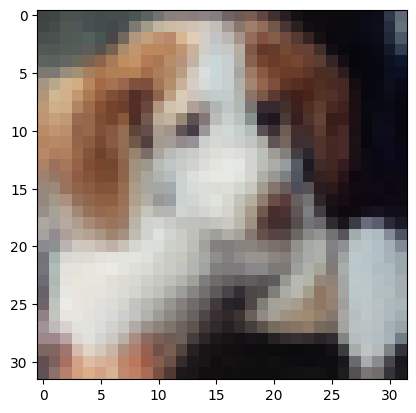

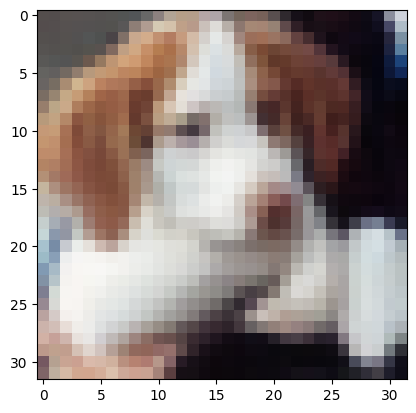

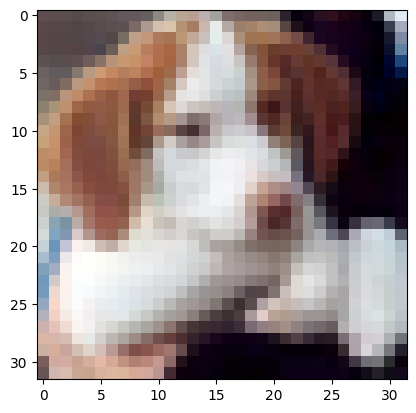

In [53]:
index = 16
plt.imshow(((samples['x_NOISY'] + 1) / 2)[index].permute(1, 2, 0).numpy())
plt.show()
plt.imshow(((samples['x_noisy'] + 1) / 2)[index].permute(1, 2, 0).numpy())
plt.show()
plt.imshow(((samples['x'] + 1) / 2)[index].permute(1, 2, 0).numpy())
plt.show()

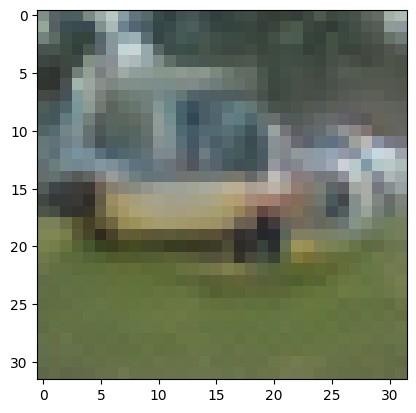

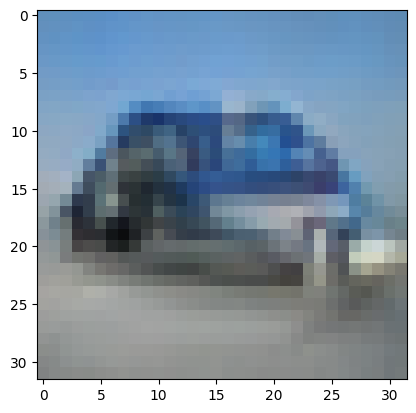

In [122]:
cfg_scale=2.0
do_enc_cfg=False
do_dec_cfg=False
T=4
r=1.0

seq_len = (img_size // patch_size) ** 2
with torch.inference_mode():
    samples = model.model.spherefiy.sample(
        model.model.encoder, 
        model.model.decoder, 
        latent_shape=(2, seq_len, latent_channels), 
        class_label=torch.tensor([1, 1], device="cpu"), 
        cfg_scale=2.0, do_enc_cfg=True, 
        do_dec_cfg=True, 
        T=4, 
        r=1.0, 
        device="cpu"
    )

plt.imshow((samples[0].detach().permute(1, 2, 0).numpy() + 1) / 2)
plt.show()
plt.imshow((samples[1].detach().permute(1, 2, 0).numpy() + 1) / 2)
plt.show()

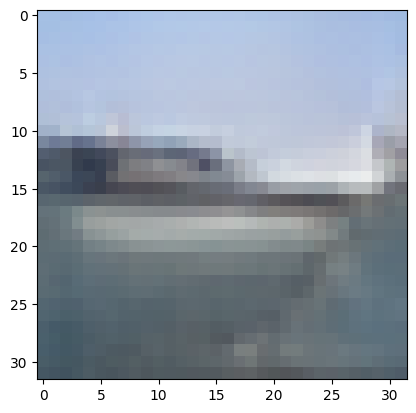

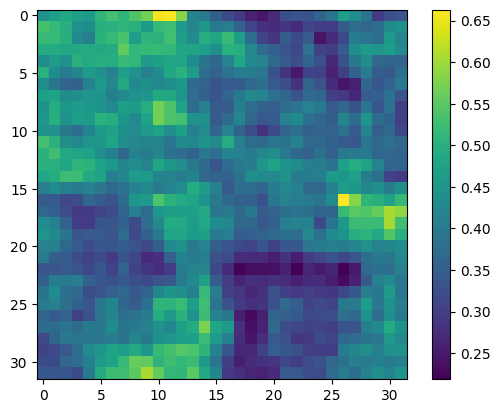

In [26]:
import matplotlib.pyplot as plt
plt.imshow((samples[0, 2].detach().numpy() + 1) / 2)
plt.colorbar()